In [12]:
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [13]:
##-- INDEX EVENT: BORROW & OUTCOME EVENT: DEPOSIT --##
df = pd.read_csv('/home/dgxuser40/manjil/finsurv/data/input_data/Borrow/Deposit/train.csv')
df.head()

,userActiveDaysWeekly,marketLiquidationSumUSD,marketLiquidationAvgAmountUSD,userBorrowSum,user,userDepositAvgAmountUSD,cosQuarter,userWithdrawAvgAmountUSD,userRepaySumUSD,userLiquidationAvgAmountUSD,...,amountUSD,userBorrowCount,cosDayOfQuarter,marketRepayCount,userBorrowSumUSD,userWithdrawSum,userDepositAvgAmount,userReserveMode,cosDayOfMonth,reserve
0,1.0,0.0,0.0,0.20000,0x4dee144e4d60ad8ae3e4b53e09669349dc0e23da,1.000000,6.123234e-17,0.0,0.0,0.0,...,0.199924,1,0.509933,0.0,0.199924,0.0,1.000000,DAI,-0.978148,other
1,1.0,0.0,0.0,0.79299,0x010afb8548a5d1a3a3d62f58ca0a5a1329974206,14.078625,6.123234e-17,0.0,0.0,0.0,...,0.793127,1,0.509933,0.0,0.793127,0.0,10.000000,DAI,-0.978148,other
2,1.0,0.0,0.0,1.00000,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,7.024463,6.123234e-17,0.0,0.0,0.0,...,0.999869,1,0.509933,0.0,0.999869,0.0,5.000000,USDC,-0.978148,USDC
3,1.0,0.0,0.0,15.00000,0x9f60699ce23f1ab86ec3e095b477ff79d4f409ad,27.100160,6.123234e-17,0.0,0.0,0.0,...,12.615414,3,0.509933,2.0,18.615467,0.0,26.500000,WPOL,-0.978148,WPOL
4,1.0,0.0,0.0,50.00000,0x005f16f017aa933bb41965b52848ceb8ee48b171,214.794320,6.123234e-17,0.0,0.0,0.0,...,55.015000,1,0.509933,2.0,55.015000,0.0,1.697614,jEUR,-0.978148,other


In [14]:
df.shape

(882736, 92)

In [15]:
df.keys()

Index(['userActiveDaysWeekly', 'marketLiquidationSumUSD',
       'marketLiquidationAvgAmountUSD', 'userBorrowSum', 'user',
       'userDepositAvgAmountUSD', 'cosQuarter', 'userWithdrawAvgAmountUSD',
       'userRepaySumUSD', 'userLiquidationAvgAmountUSD', 'userRepayCount',
       'cosDayOfYear', 'marketWithdrawSumUSD', 'type', 'userWithdrawAvgAmount',
       'marketRepayAvgAmount', 'marketDepositCount', 'userBorrowAvgAmount',
       'marketLiquidationCount', 'userSecondsSinceFirstTransaction',
       'sinDayOfQuarter', 'userDepositCount', 'quarter', 'dayOfYear',
       'userRepayAvgAmount', 'marketBorrowCount', 'marketLiquidationAvgAmount',
       'status', 'userWithdrawCount', 'sinTimeOfDay', 'cosDayOfWeek',
       'marketWithdrawCount', 'marketRepayAvgAmountUSD', 'amount',
       'userLiquidationAvgAmount', 'logAmount', 'priceInUSD',
       'marketBorrowSum', 'marketDepositAvgAmountUSD', 'marketRepaySum',
       'timeDiff', 'cosTimeOfDay', 'userDepositSumUSD', 'sinDayOfYear',
       

## Non-parametric model [Kaplan Meier Curve]

Text(0, 0.5, 'Probability')

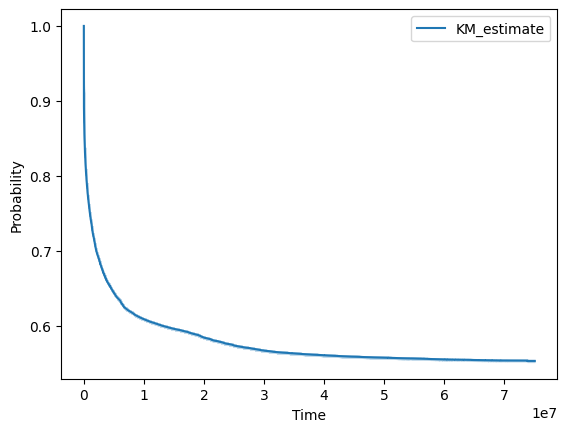

In [16]:
T = df["timeDiff"]
E = df["status"] # 0 or 1

kmf = KaplanMeierFitter()
kmf.fit(durations = T, event_observed = E)
kmf.plot_survival_function()
plt.xlabel('Time')
plt.ylabel('Probability')

<Axes: xlabel='timeline'>

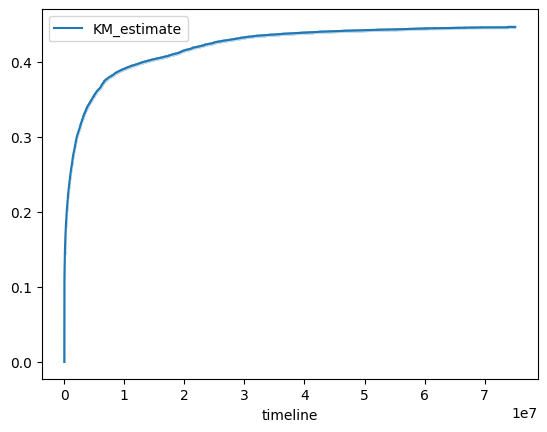

In [17]:
# plots the cumulative density function (CDF) of events over time.
kmf.plot_cumulative_density()

## Cox Proportional Hazard Model

In [18]:
df.head()

,userActiveDaysWeekly,marketLiquidationSumUSD,marketLiquidationAvgAmountUSD,userBorrowSum,user,userDepositAvgAmountUSD,cosQuarter,userWithdrawAvgAmountUSD,userRepaySumUSD,userLiquidationAvgAmountUSD,...,amountUSD,userBorrowCount,cosDayOfQuarter,marketRepayCount,userBorrowSumUSD,userWithdrawSum,userDepositAvgAmount,userReserveMode,cosDayOfMonth,reserve
0,1.0,0.0,0.0,0.20000,0x4dee144e4d60ad8ae3e4b53e09669349dc0e23da,1.000000,6.123234e-17,0.0,0.0,0.0,...,0.199924,1,0.509933,0.0,0.199924,0.0,1.000000,DAI,-0.978148,other
1,1.0,0.0,0.0,0.79299,0x010afb8548a5d1a3a3d62f58ca0a5a1329974206,14.078625,6.123234e-17,0.0,0.0,0.0,...,0.793127,1,0.509933,0.0,0.793127,0.0,10.000000,DAI,-0.978148,other
2,1.0,0.0,0.0,1.00000,0x39d637737cc76c5849a52c7d3b872a1eb22aa71c,7.024463,6.123234e-17,0.0,0.0,0.0,...,0.999869,1,0.509933,0.0,0.999869,0.0,5.000000,USDC,-0.978148,USDC
3,1.0,0.0,0.0,15.00000,0x9f60699ce23f1ab86ec3e095b477ff79d4f409ad,27.100160,6.123234e-17,0.0,0.0,0.0,...,12.615414,3,0.509933,2.0,18.615467,0.0,26.500000,WPOL,-0.978148,WPOL
4,1.0,0.0,0.0,50.00000,0x005f16f017aa933bb41965b52848ceb8ee48b171,214.794320,6.123234e-17,0.0,0.0,0.0,...,55.015000,1,0.509933,2.0,55.015000,0.0,1.697614,jEUR,-0.978148,other


In [19]:
new_df = df[['timeDiff', 'status', 'userActiveDaysWeekly', 
'marketLiquidationSumUSD', 'marketLiquidationAvgAmountUSD', 
'userDepositAvgAmountUSD', 'cosQuarter', 'userWithdrawAvgAmountUSD', 'userRepaySumUSD', 'userLiquidationAvgAmountUSD']]
new_df.head()

,timeDiff,status,userActiveDaysWeekly,marketLiquidationSumUSD,marketLiquidationAvgAmountUSD,userDepositAvgAmountUSD,cosQuarter,userWithdrawAvgAmountUSD,userRepaySumUSD,userLiquidationAvgAmountUSD
0,75091143.0,0.0,1.0,0.0,0.0,1.000000,6.123234e-17,0.0,0.0,0.0
1,75079746.0,0.0,1.0,0.0,0.0,14.078625,6.123234e-17,0.0,0.0,0.0
2,75078026.0,0.0,1.0,0.0,0.0,7.024463,6.123234e-17,0.0,0.0,0.0
3,75076842.0,0.0,1.0,0.0,0.0,27.100160,6.123234e-17,0.0,0.0,0.0
4,75076466.0,0.0,1.0,0.0,0.0,214.794320,6.123234e-17,0.0,0.0,0.0


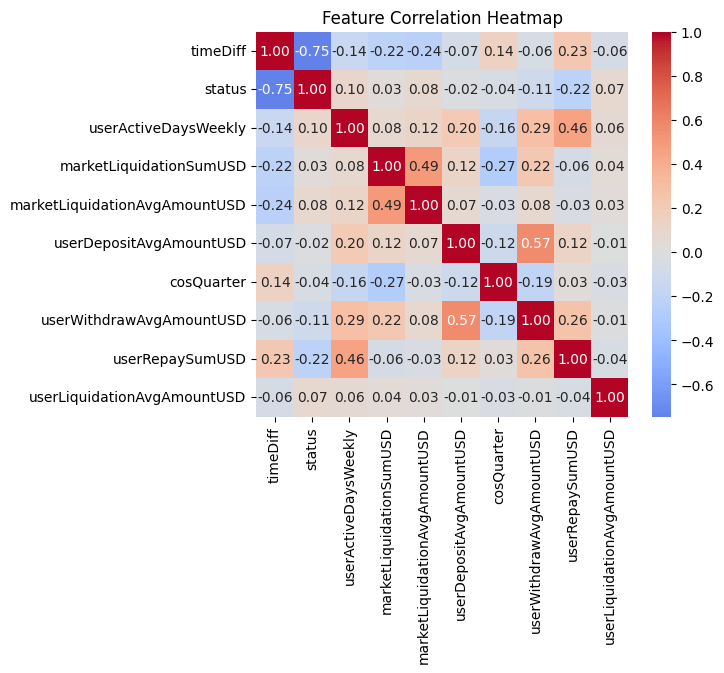

In [20]:
import seaborn as sns

corr = new_df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
from lifelines import CoxPHFitter

cph = CoxPHFitter()
cph.fit(new_df, duration_col='timeDiff', event_col='status')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 882736 total observations, 504835 right-censored observations>
             duration col = 'timeDiff'
                event col = 'status'
      baseline estimation = breslow
   number of observations = 882736
number of events observed = 377901
   partial log-likelihood = -4995286.46
         time fit was run = 2025-09-16 14:30:36 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
userActiveDaysWeekly           0.19      1.21      0.00            0.19            0.19                1.21                1.21
marketLiquidationSumUSD        0.00      1.00      0.00            0.00            0.00                1.00                1.00
marketLiquidationAvgAmountUSD  0.00      1.00      0.00            0.00            0.00                1.00                1.00
userDepositAvgAmountUSD        0.00      1.00      0.00            0.00            0.00                1.00                1.00
cosQuarter                    -0.10      0.91      0.00           -0.10           -0.09                0.90                0.91
userWithdrawAvgAmountUSD      -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
userRepaySumUSD               -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
userLiquidationAvgAmountUSD    0.00      1.00      0.00            0.00            0.00                1.00                1.00

                               cmp to       z      p  -log2(p)
covariate                                                     
userActiveDaysWeekly             0.00  261.80 <0.005       inf
marketLiquidationSumUSD          0.00    8.20 <0.005     51.88
marketLiquidationAvgAmountUSD    0.00   40.30 <0.005       inf
userDepositAvgAmountUSD          0.00    4.14 <0.005     14.82
cosQuarter                       0.00  -43.06 <0.005       inf
userWithdrawAvgAmountUSD         0.00  -79.68 <0.005       inf
userRepaySumUSD                  0.00 -210.08 <0.005       inf
userLiquidationAvgAmountUSD      0.00   50.82 <0.005       inf
---
Concordance = 0.68
Partial AIC = 9990588.92
log-likelihood ratio test = 139543.59 on 8 df
-log2(p) of ll-ratio test = inf

## Parametric [Acclerated Failure Time Model (AFT)]

In [22]:
# import parametric univariate survival models from lifelines
from lifelines import WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter

# instantiate each fitter (create model objects)
wb = WeibullFitter()        # weibull distribution
ex = ExponentialFitter()    # exponential distribution
log = LogNormalFitter()     # log-normal distribution
loglogis = LogLogisticFitter()  # log-logistic distribution

# list of all models
models = [wb, ex, log, loglogis]

# loop through each model to fit to the data and print AIC
for model in models:
    model.fit(durations=new_df["timeDiff"], event_observed=new_df["status"])
    
    # print the AIC (Akaike Information Criterion) for the model
    # lower AIC = better model fit (penalizes for complexity)
    print("The AIC value for", model.__class__.__name__, "is", model.AIC_)

The AIC value for WeibullFitter is 12192411.578060104
The AIC value for ExponentialFitter is 14247455.275756532
The AIC value for LogNormalFitter is 12167625.67210522
The AIC value for LogLogisticFitter is 12179526.286603782


In [23]:
wb.print_summary(3)

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 882736 total observations, 504835 right-censored observations>
   number of observations = 882736
number of events observed = 377901
           log-likelihood = -6096203.789
               hypothesis = lambda_ != 1, rho_ != 1

---
                 coef    se(coef)  coef lower 95%  coef upper 95%
lambda_ 496583065.987 4613693.964   487540391.983   505625739.992
rho_            0.210       0.000           0.209           0.210

         cmp to         z       p  -log2(p)
lambda_   1.000   107.632 <0.0005       inf
rho_      1.000 -2503.686 <0.0005       inf
---
AIC = 12192411.578

In [24]:
# import parametric covariates (multivariate) survival models from lifelines
from lifelines import WeibullAFTFitter

weibull_aft = WeibullAFTFitter() 

weibull_aft.fit(
    new_df, 
    duration_col='timeDiff', 
    event_col='status', 
)

weibull_aft.print_summary(3)

<lifelines.WeibullAFTFitter: fitted with 882736 total observations, 504835 right-censored observations>
             duration col = 'timeDiff'
                event col = 'status'
   number of observations = 882736
number of events observed = 377901
           log-likelihood = -6022859.452
         time fit was run = 2025-09-16 14:34:41 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                       
lambda_ cosQuarter                     0.443     1.557     0.010           0.423           0.463               1.527               1.589
        marketLiquidationAvgAmountUSD -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
        marketLiquidationSumUSD       -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
        userActiveDaysWeekly          -0.858     0.424     0.003          -0.865          -0.851               0.421               0.427
        userDepositAvgAmountUSD       -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
        userLiquidationAvgAmountUSD   -0.000     1.000     0.000          -0.000          -0.000               1.000               1.000
        userRepaySumUSD                0.000     1.000     0.000           0.000           0.000               1.000               1.000
        userWithdrawAvgAmountUSD       0.000     1.000     0.000           0.000           0.000               1.000               1.000
        Intercept                     22.589 6.458e+09     0.019          22.552          22.625           6.227e+09           6.698e+09
rho_    Intercept                     -1.493     0.225     0.001          -1.496          -1.490               0.224               0.225

                                       cmp to         z       p  -log2(p)
param   covariate                                                        
lambda_ cosQuarter                      0.000    43.823 <0.0005       inf
        marketLiquidationAvgAmountUSD   0.000   -49.921 <0.0005       inf
        marketLiquidationSumUSD         0.000   -16.403 <0.0005   198.454
        userActiveDaysWeekly            0.000  -255.518 <0.0005       inf
        userDepositAvgAmountUSD         0.000    -5.057 <0.0005    21.165
        userLiquidationAvgAmountUSD     0.000   -48.388 <0.0005       inf
        userRepaySumUSD                 0.000   209.223 <0.0005       inf
        userWithdrawAvgAmountUSD        0.000    75.935 <0.0005       inf
        Intercept                       0.000  1215.603 <0.0005       inf
rho_    Intercept                       0.000 -1011.536 <0.0005       inf
---
Concordance = 0.678
AIC = 12045738.904
log-likelihood ratio test = 146688.675 on 8 df
-log2(p) of ll-ratio test = inf

## BarPlot

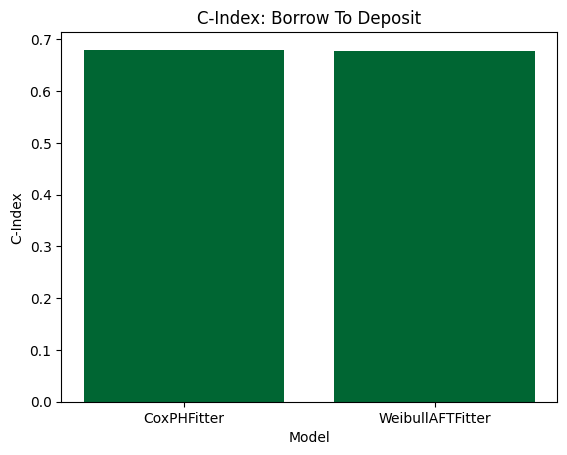

In [25]:
import matplotlib.pyplot as plt

model = ['CoxPHFitter', 'WeibullAFTFitter']
c_index = [0.68, 0.678]

plt.bar(model, c_index, color='#006633')
plt.title('C-Index: Borrow To Deposit')
plt.xlabel('Model')
plt.ylabel('C-Index')
plt.show()